# Convolutional Neural Network (CNN) Implementation [100 points]

In [10]:
# Import necessary libraries
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np
import torch.nn.functional as F

## 1. Load and preprocess the data

Load the training and test datasets, and preprocess the data by converting it to tensors and normalizing it.

In [18]:
def load_and_preprocess_data(batch_size=32):
    """
    Load the CIFAR-10 dataset and preprocess it by:
    - Converting images to tensors
    - Normalizing the data

    Args:
        batch_size (int): The batch size for training and testing.

    Returns:
        trainloader (DataLoader): DataLoader for the training dataset.
        testloader (DataLoader): DataLoader for the testing dataset.
    """
    # Implement your code
    transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
    ])

    trainset = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
    test_dataset = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)

    trainloader = DataLoader(trainset, batch_size=batch_size, shuffle=True, num_workers=4)
    testloader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=4)

    return trainloader, testloader

## 2. Split the data into training, validation, and test sets
Visualize a subset of the training dataset to get an understanding of what the data looks like.

In [12]:
def visualize_data(trainloader, num_images=6):
    """
    Visualize a subset of images from the training dataset.

    Args:
        trainloader (DataLoader): The DataLoader object for the training dataset.
        num_images (int): The number of images to visualize.

    Returns:
        None
    """
    # Implement your code

    data_iter = iter(trainloader)
    images, labels = next(data_iter)

    images = images[:num_images]
    labels = labels[:num_images]

    # normal
    images = images / 2 + 0.5

    # convert to numpy
    images_np = images.numpy()

    # blit shit
    fig, axes = plt.subplots(1, num_images, figsize=(12,6))
    for i, ax in enumerate(axes):
        img = np.transpose(images_np[i], (1, 2, 0))
        ax.imshow(img)
        ax.axis('off')
        ax.set_title(f"Label: {labels[i].item}")

    plt.tight_layout()
    plt.show()

    # no return :')


## 3. Define the CNN class
**Implement the CNN model architecture using PyTorch, ensuring it aligns with the following design:**

#### Layer 1
* 3 x 3 conv. 96 ReLU (Input 32 x 32 RGB image, dropout = 0.2)
* 3 x 3 conv. 96 ReLU
---------------
#### Replace max pooling with CNN
* 3 x 3 conv. 96 ReLU, stride r = 2, dropout = 0.5
--------------
#### Layer 2
* 3 x 3 conv. 192 ReLU
* 3 x 3 conv. 192 ReLU
--------------
#### Replace max pooling with CNN
* 3 x 3 conv. 192, stride r = 2, dropout = 0.5
--------------
#### Layer 3
* 3 x 3 conv. 192 ReLU
-------------
#### Layer 4
* 1 x 1 conv. 192 ReLU
--------------
#### Layer 5
* 1 x 1 conv. 10 ReLU
--------------
#### Global averaging
-------------
#### Output layer
* 10 or 100-way softmax

In [20]:
class CNNModel(nn.Module):
    """
    Define a simple CNN model architecture for CIFAR-10 classification.
    """
    def __init__(self):
        super(CNNModel, self).__init__()

        # Implement your code

        # 1
        self.conv1_1 = nn.Conv2d(in_channels=3, out_channels=96, kernel_size=3, padding=1)
        self.conv1_2 = nn.Conv2d(in_channels=96, out_channels=96, kernel_size=3, padding=1)
        self.conv1_3 = nn.Conv2d(in_channels=96, out_channels=96, kernel_size=3, stride=2, padding=1)
        self.dropout1 = nn.Dropout(0.5)

        # 2
        self.conv2_1 = nn.Conv2d(in_channels=96, out_channels=192, kernel_size=3, padding=1)
        self.conv2_2 = nn.Conv2d(in_channels=192, out_channels=192, kernel_size=3, padding=1)
        self.conv2_3 = nn.Conv2d(in_channels=192, out_channels=192, kernel_size=3, stride=2, padding=1)
        self.dropout2 = nn.Dropout(0.5)

        # 3
        self.conv3 = nn.Conv2d(in_channels=192, out_channels=192, kernel_size=3, padding=1)

        # 4
        self.conv4 = nn.Conv2d(in_channels=192, out_channels=192, kernel_size=1)

        # 5
        self.conv5 = nn.Conv2d(in_channels=192, out_channels=10, kernel_size=1)

        #averages
        self.global_avg_pool = nn.AdaptiveAvgPool2d((1, 1))


    def forward(self, x):
        # Implement your code
        # 1
        x = F.relu(self.conv1_1(x))
        x = F.relu(self.conv1_2(x))
        x = self.dropout1(F.relu(self.conv1_3(x)))

        # 2
        x = F.relu(self.conv2_1(x))
        x = F.relu(self.conv2_2(x))
        x = self.dropout2(F.relu(self.conv2_3(x)))

        # 3
        x = F.relu(self.conv3(x))

        # 4
        x = F.relu(self.conv4(x))

        # 5
        x = F.relu(self.conv5(x))

        # averageing
        x = self.global_avg_pool(x)

        # flattn and softmax
        x = torch.flatten(x,1)

        return F.log_softmax(x,dim=1)


## Train the model and track the training process
Train the model on the training set, while monitoring and logging training loss and accuracy throughout the epochs.

In [22]:
def train_model(model, trainloader, criterion, optimizer, device, epochs=10):
    """
    Train the CNN model.

    Args:
        model (nn.Module): The CNN model to train.
        trainloader (DataLoader): DataLoader for the training dataset.
        criterion (nn.Module): The loss function.
        optimizer (optim.Optimizer): The optimizer.
        epochs (int): Number of epochs to train.

    Returns:
        train_losses (list): List of training losses for each epoch.
        train_accuracies (list): List of training accuracies for each epoch.
    """
    # Implement your code

    train_losses = []
    train_accuracies = []

    model.to(device)

    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        correct = 0
        total = 0

        for inputs, labels in trainloader:
            inputs, labels = inputs.to(device), labels.to(device)

            optimizer.zero_grad()

            outputs = model(inputs)
            loss = criterion(outputs, labels)

            loss.backward()
            optimizer.step()

            running_loss += loss.item() * inputs.size(0)

            _, predicted = torch.max(outputs,1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

        epoch_loss = running_loss / len(trainloader.dataset)
        epoch_accuracy = 100 * correct / total

        train_losses.append(epoch_loss)
        train_accuracies.append(epoch_accuracy)

        # phone home progress
        print(f"Epoch {epoch+1}/{epochs}, Loss: {epoch_loss:.4f}, Accuracy: {epoch_accuracy:.2f}%")

    return train_losses, train_accuracies

## Evaluate the model and visualize model predictions
Evaluate the model on the test set to compute the accuracy and loss. Visualize predictions on a subset of the test set, showing the predicted labels and whether they are correct or incorrect.

In [15]:
def evaluate_model(model, testloader, device):
    """
    Evaluate the CNN model on the test dataset.

    Args:
        model (nn.Module): The trained CNN model.
        testloader (DataLoader): DataLoader for the test dataset.

    Returns:
        accuracy (float): Test accuracy of the model.
        loss (float): Test loss of the model.
    """
    # Implement your code

    model.to(device)
    model.eval()

    total_loss = 0.0
    correct = 0
    total = 0

    criterion = nn.CrossEntropyLoss()

    with torch.no_grad():
        for inputs, labels in testloader:
            inputs, labels = inputs.to(device), labels.to(device)

            outputs = model(inputs)
            loss = criterion(outputs, labels)

            total_loss += loss.item() * inputs.size(0)

            _, predicted = torch.max(outputs,1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    accuracy = 100 * correct / total
    loss = total_loss / len(testloader.dataset)

    print(f"Test Loss: {loss:.4f}, Test Accuracy: {accuracy:.2f}%")

    return accuracy, loss

In [16]:
# Visualize model predictions
def visualize_predictions(model, testloader, device):
    """
    Visualize model predictions on a subset of the test dataset.

    Args:
        model (nn.Module): The trained CNN model.
        testloader (DataLoader): DataLoader for the test dataset.

    Returns:
        None
    """
    # Implement your code

    model.to(device)
    model.eval()

    data_iter = iter(testloader)
    images, labels = next(data_iter)

    images, labels = images.to(device), labels.to(device)

    with torch.no_grad():
        outputs = model(images)
        _, predicted = torch.max(outputs,1)

    images = images.cpu()
    labels = labels.cpu()
    predicted = predicted.cpu()

    mean = np.array([0.5, 0.5, 0.5])
    std = np.array([0.5, 0.5, 0.5])
    images = images.permute(0,2,3,1).numpy() * std + mean

    num_images = min(len(images), 6)
    plt.figure(figsize=(12,6))
    for idx in range(num_images):
        plt.subplot(2,3,idx + 1)
        plt.imshow(np.clip(images[idx],0,1))
        plt.title(f"True: {labels[idx]}.item(), pred: {predicted[idx].item()}")
        plt.axis('off')

    plt.tight_layout()
    plt.show()

## Test your code

Files already downloaded and verified
Files already downloaded and verified


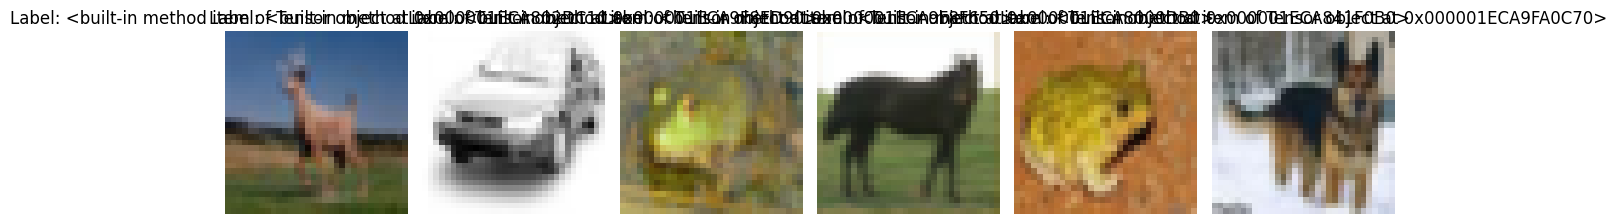

Epoch 1/10, Loss: 2.3028, Accuracy: 10.30%
Epoch 2/10, Loss: 2.3026, Accuracy: 10.00%
Epoch 3/10, Loss: 2.3026, Accuracy: 10.00%
Epoch 4/10, Loss: 2.3026, Accuracy: 10.00%
Epoch 5/10, Loss: 2.3026, Accuracy: 10.00%
Epoch 6/10, Loss: 2.3026, Accuracy: 10.00%
Epoch 7/10, Loss: 2.3026, Accuracy: 10.00%
Epoch 8/10, Loss: 2.3026, Accuracy: 10.00%
Epoch 9/10, Loss: 2.3026, Accuracy: 10.00%
Epoch 10/10, Loss: 2.3026, Accuracy: 10.00%


TypeError: evaluate_model() missing 1 required positional argument: 'device'

In [23]:

# Main function to validate the final result
def main():
    # Hyperparameters
    batch_size = 32              # Batch size for training
    learning_rate = 0.001        # Learning rate for optimizer
    epochs = 10                  # Number of training epochs
    weight_decay = 1e-5          # Weight decay (L2 regularization) to prevent overfitting

    # Check if GPU is available and use it
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

    # Load data
    trainloader, testloader = load_and_preprocess_data(batch_size)

    # Visualize a subset of the data
    visualize_data(trainloader)

    # Initialize model, loss function, and optimizer
    model = CNNModel().to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)

    # Train the model
    train_losses, train_accuracies = train_model(model, trainloader, criterion, optimizer, device, epochs=epochs)

    # Evaluate the model
    test_accuracy, test_loss = evaluate_model(model, testloader)

    # Visualize predictions
    visualize_predictions(model, testloader)


# Run the main function to validate the result
if __name__ == '__main__':
    main()

## Reference
[1] Springenberg, Jost Tobias, et al. "Striving for simplicity: The all convolutional net." arXiv preprint arXiv:1412.6806 (2014).